In [7]:
import os
import random
import shutil
import copy
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Torch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Torch version: 2.10.0+cu128
CUDA available: True
Using device: cuda


In [16]:
import os
import shutil
from sklearn.model_selection import train_test_split

SOURCE_DIR = "/kaggle/input/datasets/msambare/fer2013/train"

SPLIT_DIR = "/kaggle/working/fer2013_80_20_split"
TRAIN_DIR = os.path.join(SPLIT_DIR, "train")
TEST_DIR = os.path.join(SPLIT_DIR, "test")

print("Source folder:", SOURCE_DIR)
print("New train folder:", TRAIN_DIR)
print("New test folder:", TEST_DIR)

Source folder: /kaggle/input/datasets/msambare/fer2013/train
New train folder: /kaggle/working/fer2013_80_20_split/train
New test folder: /kaggle/working/fer2013_80_20_split/test


In [17]:
classes = sorted([
    folder for folder in os.listdir(SOURCE_DIR)
    if os.path.isdir(os.path.join(SOURCE_DIR, folder))
])

print("Classes:", classes)
print("Total classes:", len(classes))

for cls in classes:
    class_path = os.path.join(SOURCE_DIR, cls)

    images = [
        file for file in os.listdir(class_path)
        if file.lower().endswith((".jpg", ".jpeg", ".png", ".bmp"))
    ]

    print(f"{cls}: {len(images)} images")

Classes: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']
Total classes: 7
angry: 3995 images
disgust: 436 images
fear: 4097 images
happy: 7215 images
neutral: 4965 images
sad: 4830 images
surprise: 3171 images


In [18]:
SEED = 42

if os.path.exists(SPLIT_DIR):
    shutil.rmtree(SPLIT_DIR)

os.makedirs(TRAIN_DIR, exist_ok=True)
os.makedirs(TEST_DIR, exist_ok=True)

for cls in classes:
    source_class_dir = os.path.join(SOURCE_DIR, cls)

    images = [
        file for file in os.listdir(source_class_dir)
        if file.lower().endswith((".jpg", ".jpeg", ".png", ".bmp"))
    ]

    train_images, test_images = train_test_split(
        images,
        test_size=0.20,
        random_state=SEED,
        shuffle=True
    )

    new_train_class_dir = os.path.join(TRAIN_DIR, cls)
    new_test_class_dir = os.path.join(TEST_DIR, cls)

    os.makedirs(new_train_class_dir, exist_ok=True)
    os.makedirs(new_test_class_dir, exist_ok=True)

    for image_name in train_images:
        shutil.copy2(
            os.path.join(source_class_dir, image_name),
            os.path.join(new_train_class_dir, image_name)
        )

    for image_name in test_images:
        shutil.copy2(
            os.path.join(source_class_dir, image_name),
            os.path.join(new_test_class_dir, image_name)
        )

    print(
        f"{cls}: "
        f"Train = {len(train_images)}, "
        f"Test = {len(test_images)}"
    )

print("\n80% train and 20% test split completed.")

angry: Train = 3196, Test = 799
disgust: Train = 348, Test = 88
fear: Train = 3277, Test = 820
happy: Train = 5772, Test = 1443
neutral: Train = 3972, Test = 993
sad: Train = 3864, Test = 966
surprise: Train = 2536, Test = 635

80% train and 20% test split completed.


In [19]:
for cls in classes:
    train_count = len(os.listdir(os.path.join(TRAIN_DIR, cls)))
    test_count = len(os.listdir(os.path.join(TEST_DIR, cls)))

    print(f"{cls}: Train = {train_count}, Test = {test_count}")

print("\nTotal Train Images:", sum(
    len(os.listdir(os.path.join(TRAIN_DIR, cls)))
    for cls in classes
))

print("Total Test Images:", sum(
    len(os.listdir(os.path.join(TEST_DIR, cls)))
    for cls in classes
))

angry: Train = 3196, Test = 799
disgust: Train = 348, Test = 88
fear: Train = 3277, Test = 820
happy: Train = 5772, Test = 1443
neutral: Train = 3972, Test = 993
sad: Train = 3864, Test = 966
surprise: Train = 2536, Test = 635

Total Train Images: 22965
Total Test Images: 5744


In [21]:
from torchvision import transforms

IMG_SIZE = 224

train_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.15, contrast=0.15),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

test_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

print("Transforms created successfully.")

Transforms created successfully.


In [33]:
BATCH_SIZE = 32
NUM_WORKERS = 0   # Important: avoids multiprocessing error in Kaggle

train_dataset = datasets.ImageFolder(TRAIN_DIR, transform=train_transform)
test_dataset = datasets.ImageFolder(TEST_DIR, transform=test_transform)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

class_names = train_dataset.classes
num_classes = len(class_names)

print("Classes:", class_names)
print("Number of classes:", num_classes)
print("Train images:", len(train_dataset))
print("Test images:", len(test_dataset))

Classes: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']
Number of classes: 7
Train images: 22965
Test images: 5744


In [34]:
import torch
import torch.nn as nn
import torch.optim as optim
import copy
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from torchvision import models
from tqdm.auto import tqdm
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)

Device: cuda


In [36]:
class CustomCNN(nn.Module):
    def __init__(self, num_classes):
        super(CustomCNN, self).__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Dropout(0.20),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Dropout(0.25),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Dropout(0.30),

            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Dropout(0.35),

            nn.Conv2d(256, 512, kernel_size=3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((1, 1))
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(0.50),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

In [38]:
def create_resnet50(num_classes):
    model = models.resnet50(
        weights=models.ResNet50_Weights.IMAGENET1K_V2
    )

    # Freeze pretrained layers
    for param in model.parameters():
        param.requires_grad = False

    # Train final ResNet block
    for param in model.layer4.parameters():
        param.requires_grad = True

    # Replace classifier
    model.fc = nn.Sequential(
        nn.Dropout(0.40),
        nn.Linear(model.fc.in_features, num_classes)
    )

    return model

In [39]:
def create_efficientnet(num_classes):
    model = models.efficientnet_b0(
        weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1
    )

    # Freeze pretrained layers
    for param in model.parameters():
        param.requires_grad = False

    # Train last feature blocks
    for param in model.features[-2:].parameters():
        param.requires_grad = True

    # Replace classifier
    model.classifier = nn.Sequential(
        nn.Dropout(0.40),
        nn.Linear(model.classifier[1].in_features, num_classes)
    )

    return model

In [40]:
def train_model(model, model_name, train_loader, test_loader, epochs=15, lr=0.0001):
    model = model.to(device)

    criterion = nn.CrossEntropyLoss()

    optimizer = optim.AdamW(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=lr,
        weight_decay=1e-4
    )

    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="max",
        factor=0.5,
        patience=2
    )

    best_accuracy = 0.0
    best_weights = copy.deepcopy(model.state_dict())

    history = {
        "train_loss": [],
        "train_acc": [],
        "test_loss": [],
        "test_acc": []
    }

    for epoch in range(epochs):
        start_time = time.time()

        # -------- Training --------
        model.train()
        train_loss = 0.0
        train_correct = 0
        train_total = 0

        for images, labels in tqdm(
            train_loader,
            desc=f"{model_name} Epoch {epoch + 1}/{epochs}"
        ):
            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            outputs = model(images)
            loss = criterion(outputs, labels)

            loss.backward()
            optimizer.step()

            train_loss += loss.item() * images.size(0)

            predictions = torch.argmax(outputs, dim=1)
            train_correct += (predictions == labels).sum().item()
            train_total += labels.size(0)

        train_loss = train_loss / train_total
        train_acc = train_correct / train_total

        # -------- Testing --------
        model.eval()
        test_loss = 0.0
        test_correct = 0
        test_total = 0

        with torch.no_grad():
            for images, labels in test_loader:
                images = images.to(device)
                labels = labels.to(device)

                outputs = model(images)
                loss = criterion(outputs, labels)

                test_loss += loss.item() * images.size(0)

                predictions = torch.argmax(outputs, dim=1)
                test_correct += (predictions == labels).sum().item()
                test_total += labels.size(0)

        test_loss = test_loss / test_total
        test_acc = test_correct / test_total

        scheduler.step(test_acc)

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["test_loss"].append(test_loss)
        history["test_acc"].append(test_acc)

        if test_acc > best_accuracy:
            best_accuracy = test_acc
            best_weights = copy.deepcopy(model.state_dict())

            torch.save(
                best_weights,
                f"/kaggle/working/best_{model_name}.pth"
            )

        elapsed_time = time.time() - start_time

        print(
            f"\n{model_name} | Epoch {epoch + 1}/{epochs}"
            f"\nTrain Loss: {train_loss:.4f} | Train Accuracy: {train_acc * 100:.2f}%"
            f"\nTest Loss: {test_loss:.4f} | Test Accuracy: {test_acc * 100:.2f}%"
            f"\nTime: {elapsed_time:.1f} seconds\n"
        )

    model.load_state_dict(best_weights)

    print(f"Best {model_name} Accuracy: {best_accuracy * 100:.2f}%")

    return model, history, best_accuracy

In [41]:
customcnn_model = CustomCNN(num_classes)

customcnn_model, customcnn_history, customcnn_best_acc = train_model(
    model=customcnn_model,
    model_name="customcnn",
    train_loader=train_loader,
    test_loader=test_loader,
    epochs=30,
    lr=0.0005
)

customcnn Epoch 1/30:   0%|          | 0/718 [00:00<?, ?it/s]


customcnn | Epoch 1/30
Train Loss: 1.8005 | Train Accuracy: 25.30%
Test Loss: 1.7689 | Test Accuracy: 25.94%
Time: 141.2 seconds



customcnn Epoch 2/30:   0%|          | 0/718 [00:00<?, ?it/s]


customcnn | Epoch 2/30
Train Loss: 1.7569 | Train Accuracy: 27.93%
Test Loss: 1.7724 | Test Accuracy: 25.77%
Time: 141.6 seconds



customcnn Epoch 3/30:   0%|          | 0/718 [00:00<?, ?it/s]

...


customcnn | Epoch 28/30
Train Loss: 1.2073 | Train Accuracy: 54.07%
Test Loss: 1.1598 | Test Accuracy: 54.77%
Time: 141.5 seconds



customcnn Epoch 29/30:   0%|          | 0/718 [00:00<?, ?it/s]


customcnn | Epoch 29/30
Train Loss: 1.2063 | Train Accuracy: 54.28%
Test Loss: 1.1619 | Test Accuracy: 54.68%
Time: 141.2 seconds



customcnn Epoch 30/30:   0%|          | 0/718 [00:00<?, ?it/s]


customcnn | Epoch 30/30
Train Loss: 1.2008 | Train Accuracy: 54.36%
Test Loss: 1.1577 | Test Accuracy: 54.70%
Time: 140.4 seconds

Best customcnn Accuracy: 54.77%


In [43]:
resnet50_model = create_resnet50(num_classes)

resnet50_model, resnet50_history, resnet50_best_acc = train_model(
    model=resnet50_model,
    model_name="resnet50",
    train_loader=train_loader,
    test_loader=test_loader,
    epochs=30,
    lr=0.0001
)

resnet50 Epoch 1/30:   0%|          | 0/718 [00:00<?, ?it/s]


resnet50 | Epoch 1/30
Train Loss: 1.4498 | Train Accuracy: 43.83%
Test Loss: 1.2532 | Test Accuracy: 52.21%
Time: 200.6 seconds



resnet50 Epoch 2/30:   0%|          | 0/718 [00:00<?, ?it/s]


resnet50 | Epoch 2/30
Train Loss: 1.1918 | Train Accuracy: 54.81%
Test Loss: 1.1305 | Test Accuracy: 57.45%
Time: 200.3 seconds



resnet50 Epoch 3/30:   0%|          | 0/718 [00:00<?, ?it/s]

...


resnet50 | Epoch 28/30
Train Loss: 0.2183 | Train Accuracy: 92.16%
Test Loss: 1.4609 | Test Accuracy: 64.87%
Time: 199.7 seconds



resnet50 Epoch 29/30:   0%|          | 0/718 [00:00<?, ?it/s]


resnet50 | Epoch 29/30
Train Loss: 0.2062 | Train Accuracy: 92.65%
Test Loss: 1.5039 | Test Accuracy: 65.04%
Time: 199.9 seconds



resnet50 Epoch 30/30:   0%|          | 0/718 [00:00<?, ?it/s]


resnet50 | Epoch 30/30
Train Loss: 0.2032 | Train Accuracy: 92.81%
Test Loss: 1.5109 | Test Accuracy: 64.42%
Time: 199.6 seconds

Best resnet50 Accuracy: 65.04%


In [44]:
efficientnet_model = create_efficientnet(num_classes)

efficientnet_model, efficientnet_history, efficientnet_best_acc = train_model(
    model=efficientnet_model,
    model_name="efficientnet_b0",
    train_loader=train_loader,
    test_loader=test_loader,
    epochs=30,
    lr=0.0001
)

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 190MB/s]


efficientnet_b0 Epoch 1/30:   0%|          | 0/718 [00:00<?, ?it/s]


efficientnet_b0 | Epoch 1/30
Train Loss: 1.5921 | Train Accuracy: 37.46%
Test Loss: 1.4360 | Test Accuracy: 46.66%
Time: 119.3 seconds



efficientnet_b0 Epoch 2/30:   0%|          | 0/718 [00:00<?, ?it/s]

...


efficientnet_b0 | Epoch 28/30
Train Loss: 0.9553 | Train Accuracy: 64.18%
Test Loss: 1.0715 | Test Accuracy: 60.20%
Time: 118.2 seconds



efficientnet_b0 Epoch 29/30:   0%|          | 0/718 [00:00<?, ?it/s]


efficientnet_b0 | Epoch 29/30
Train Loss: 0.9498 | Train Accuracy: 64.22%
Test Loss: 1.0835 | Test Accuracy: 60.48%
Time: 118.5 seconds



efficientnet_b0 Epoch 30/30:   0%|          | 0/718 [00:00<?, ?it/s]


efficientnet_b0 | Epoch 30/30
Train Loss: 0.9452 | Train Accuracy: 64.56%
Test Loss: 1.0782 | Test Accuracy: 60.11%
Time: 118.2 seconds

Best efficientnet_b0 Accuracy: 60.48%


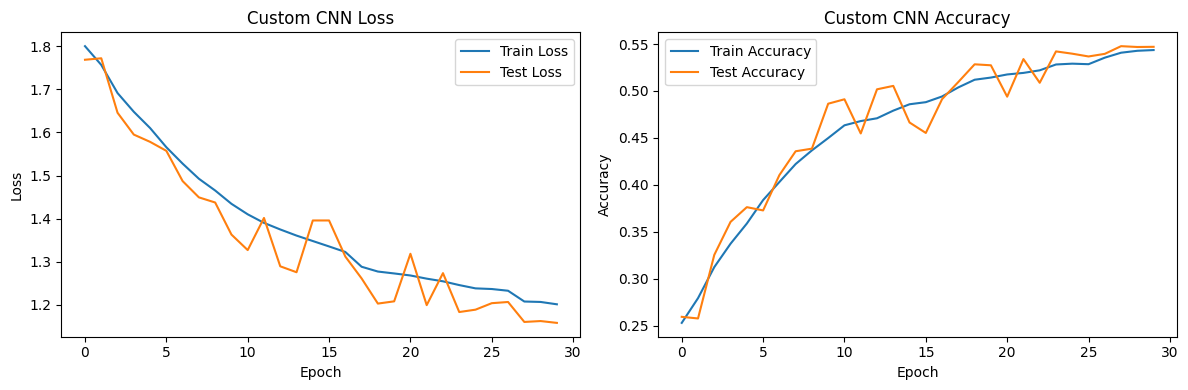

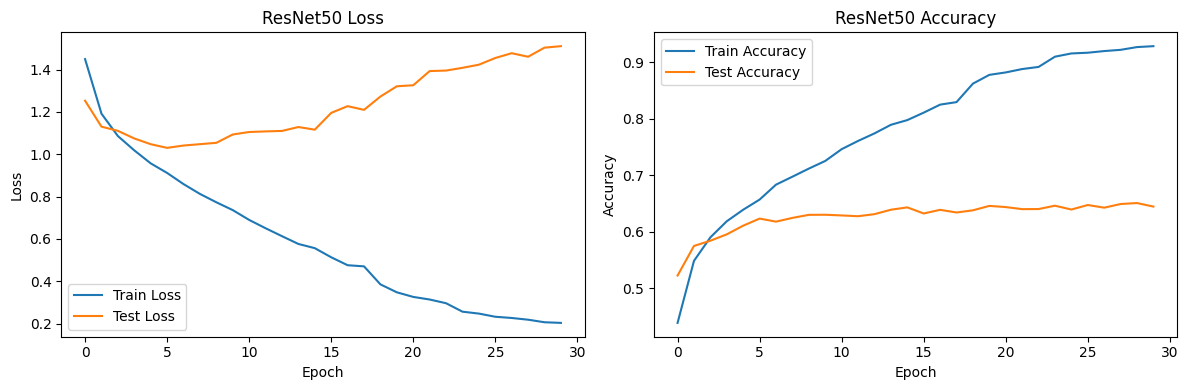

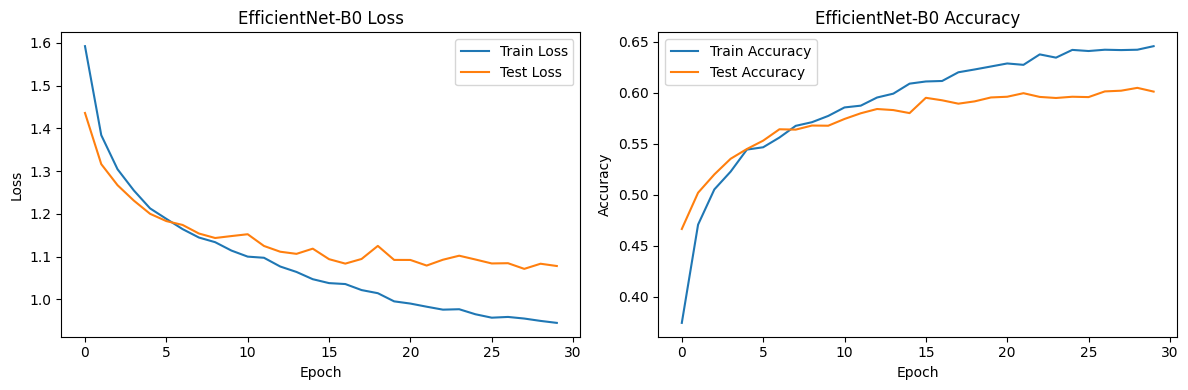

In [45]:
def plot_history(history, model_name):
    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.plot(history["train_loss"], label="Train Loss")
    plt.plot(history["test_loss"], label="Test Loss")
    plt.title(f"{model_name} Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(history["train_acc"], label="Train Accuracy")
    plt.plot(history["test_acc"], label="Test Accuracy")
    plt.title(f"{model_name} Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()

    plt.tight_layout()
    plt.show()

plot_history(customcnn_history, "Custom CNN")
plot_history(resnet50_history, "ResNet50")
plot_history(efficientnet_history, "EfficientNet-B0")

In [46]:
def get_probabilities(model, data_loader):
    model.eval()

    all_probabilities = []
    all_labels = []

    with torch.no_grad():
        for images, labels in tqdm(data_loader, desc="Collecting predictions"):
            images = images.to(device)

            outputs = model(images)
            probabilities = torch.softmax(outputs, dim=1)

            all_probabilities.append(probabilities.cpu().numpy())
            all_labels.append(labels.numpy())

    return (
        np.concatenate(all_probabilities, axis=0),
        np.concatenate(all_labels, axis=0)
    )


customcnn_probs, true_labels = get_probabilities(customcnn_model, test_loader)
resnet50_probs, _ = get_probabilities(resnet50_model, test_loader)
efficientnet_probs, _ = get_probabilities(efficientnet_model, test_loader)

print("Custom CNN:", customcnn_probs.shape)
print("ResNet50:", resnet50_probs.shape)
print("EfficientNet:", efficientnet_probs.shape)

Custom CNN: (5744, 7)
ResNet50: (5744, 7)
EfficientNet: (5744, 7)


In [47]:
customcnn_pred = np.argmax(customcnn_probs, axis=1)
resnet50_pred = np.argmax(resnet50_probs, axis=1)
efficientnet_pred = np.argmax(efficientnet_probs, axis=1)

customcnn_acc = accuracy_score(true_labels, customcnn_pred)
resnet50_acc = accuracy_score(true_labels, resnet50_pred)
efficientnet_acc = accuracy_score(true_labels, efficientnet_pred)

print("Custom CNN Accuracy:", round(customcnn_acc * 100, 2), "%")
print("ResNet50 Accuracy:", round(resnet50_acc * 100, 2), "%")
print("EfficientNet-B0 Accuracy:", round(efficientnet_acc * 100, 2), "%")

Custom CNN Accuracy: 54.77 %
ResNet50 Accuracy: 65.04 %
EfficientNet-B0 Accuracy: 60.48 %


In [51]:
import numpy as np
from tqdm.auto import tqdm
from sklearn.metrics import accuracy_score

def dempster_rule(mass_1, mass_2, epsilon=1e-12):
    """
    Normal Dempster-Shafer combination rule.
    mass_1 and mass_2 are probability/belief vectors for one image.
    """

    num_classes = len(mass_1)
    combined_mass = np.zeros(num_classes)
    conflict = 0.0

    for i in range(num_classes):
        for j in range(num_classes):
            if i == j:
                combined_mass[i] += mass_1[i] * mass_2[j]
            else:
                conflict += mass_1[i] * mass_2[j]

    denominator = 1.0 - conflict

    # In case of very high conflict between two models
    if denominator <= epsilon:
        return (mass_1 + mass_2) / 2.0

    combined_mass = combined_mass / denominator
    combined_mass = combined_mass / (combined_mass.sum() + epsilon)

    return combined_mass

In [52]:
def normal_dst_fusion(probabilities_list, combination_name="DST Fusion"):
    """
    probabilities_list can contain 2 or 3 model probability arrays.

    Example:
    [customcnn_probs, resnet50_probs]
    """

    total_samples = probabilities_list[0].shape[0]
    total_classes = probabilities_list[0].shape[1]

    fused_scores = np.zeros((total_samples, total_classes))

    for sample_index in tqdm(
        range(total_samples),
        desc=f"Applying {combination_name}"
    ):
        fused_mass = probabilities_list[0][sample_index]

        for model_index in range(1, len(probabilities_list)):
            fused_mass = dempster_rule(
                fused_mass,
                probabilities_list[model_index][sample_index]
            )

        fused_scores[sample_index] = fused_mass

    fused_predictions = np.argmax(fused_scores, axis=1)

    return fused_predictions, fused_scores

In [53]:
cnn_resnet_pred, cnn_resnet_scores = normal_dst_fusion(
    probabilities_list=[
        customcnn_probs,
        resnet50_probs
    ],
    combination_name="CustomCNN + ResNet50 DST"
)

cnn_resnet_acc = accuracy_score(true_labels, cnn_resnet_pred)

print("CustomCNN + ResNet50 DST Accuracy:", round(cnn_resnet_acc * 100, 2), "%")

Applying CustomCNN + ResNet50 DST:   0%|          | 0/5744 [00:00<?, ?it/s]

CustomCNN + ResNet50 DST Accuracy: 66.1 %


In [54]:
cnn_efficientnet_pred, cnn_efficientnet_scores = normal_dst_fusion(
    probabilities_list=[
        customcnn_probs,
        efficientnet_probs
    ],
    combination_name="CustomCNN + EfficientNet DST"
)

cnn_efficientnet_acc = accuracy_score(true_labels, cnn_efficientnet_pred)

print(
    "CustomCNN + EfficientNet-B0 DST Accuracy:",
    round(cnn_efficientnet_acc * 100, 2),
    "%"
)

Applying CustomCNN + EfficientNet DST:   0%|          | 0/5744 [00:00<?, ?it/s]

CustomCNN + EfficientNet-B0 DST Accuracy: 60.88 %


In [55]:
resnet_efficientnet_pred, resnet_efficientnet_scores = normal_dst_fusion(
    probabilities_list=[
        resnet50_probs,
        efficientnet_probs
    ],
    combination_name="ResNet50 + EfficientNet DST"
)

resnet_efficientnet_acc = accuracy_score(
    true_labels,
    resnet_efficientnet_pred
)

print(
    "ResNet50 + EfficientNet-B0 DST Accuracy:",
    round(resnet_efficientnet_acc * 100, 2),
    "%"
)

Applying ResNet50 + EfficientNet DST:   0%|          | 0/5744 [00:00<?, ?it/s]

ResNet50 + EfficientNet-B0 DST Accuracy: 67.01 %


In [56]:
all_models_pred, all_models_scores = normal_dst_fusion(
    probabilities_list=[
        customcnn_probs,
        resnet50_probs,
        efficientnet_probs
    ],
    combination_name="CustomCNN + ResNet50 + EfficientNet DST"
)

all_models_acc = accuracy_score(true_labels, all_models_pred)

print(
    "CustomCNN + ResNet50 + EfficientNet-B0 DST Accuracy:",
    round(all_models_acc * 100, 2),
    "%"
)

Applying CustomCNN + ResNet50 + EfficientNet DST:   0%|          | 0/5744 [00:00<?, ?it/s]

CustomCNN + ResNet50 + EfficientNet-B0 DST Accuracy: 67.53 %


In [57]:
results_df = pd.DataFrame({
    "Model / Combination": [
        "Custom CNN",
        "ResNet50",
        "EfficientNet-B0",
        "CustomCNN + ResNet50 (Normal DST)",
        "CustomCNN + EfficientNet-B0 (Normal DST)",
        "ResNet50 + EfficientNet-B0 (Normal DST)",
        "CustomCNN + ResNet50 + EfficientNet-B0 (Normal DST)"
    ],
    "Test Accuracy (%)": [
        round(customcnn_acc * 100, 2),
        round(resnet50_acc * 100, 2),
        round(efficientnet_acc * 100, 2),
        round(cnn_resnet_acc * 100, 2),
        round(cnn_efficientnet_acc * 100, 2),
        round(resnet_efficientnet_acc * 100, 2),
        round(all_models_acc * 100, 2)
    ]
})

results_df = results_df.sort_values(
    by="Test Accuracy (%)",
    ascending=False
).reset_index(drop=True)

results_df

,Model / Combination,Test Accuracy (%)
0,CustomCNN + ResNet50 + EfficientNet-B0 (Normal...,67.53
1,ResNet50 + EfficientNet-B0 (Normal DST),67.01
2,CustomCNN + ResNet50 (Normal DST),66.10
3,ResNet50,65.04
4,CustomCNN + EfficientNet-B0 (Normal DST),60.88
5,EfficientNet-B0,60.48
6,Custom CNN,54.77


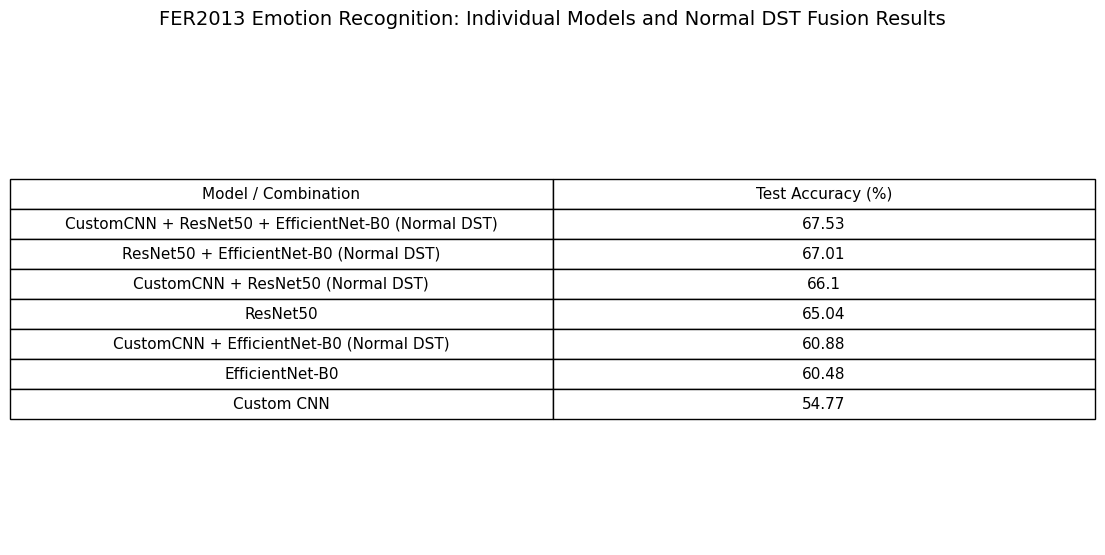

PNG saved at:
/kaggle/working/fer2013_all_normal_dst_combinations.png


In [58]:
import matplotlib.pyplot as plt

# Create figure based on number of rows
fig_height = len(results_df) * 0.7 + 1.5

fig, ax = plt.subplots(figsize=(14, fig_height))
ax.axis("off")

table = ax.table(
    cellText=results_df.values,
    colLabels=results_df.columns,
    cellLoc="center",
    loc="center"
)

table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1, 1.8)

plt.title(
    "FER2013 Emotion Recognition: Individual Models and Normal DST Fusion Results",
    fontsize=14,
    pad=20
)

plt.savefig(
    "/kaggle/working/fer2013_all_normal_dst_combinations.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("PNG saved at:")
print("/kaggle/working/fer2013_all_normal_dst_combinations.png")

Using image: /kaggle/input/datasets/cbinayak70/my-dataset/happy.jpeg


Applying CNN + ResNet50 DST:   0%|          | 0/1 [00:00<?, ?it/s]

Applying CNN + EfficientNet-B0 DST:   0%|          | 0/1 [00:00<?, ?it/s]

Applying ResNet50 + EfficientNet-B0 DST:   0%|          | 0/1 [00:00<?, ?it/s]

Applying CNN + ResNet50 + EfficientNet-B0 DST:   0%|          | 0/1 [00:00<?, ?it/s]

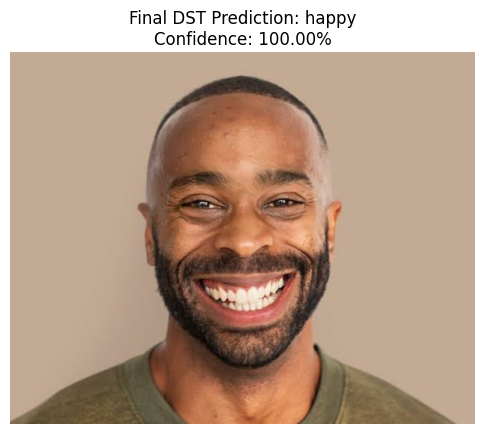

,Model / Combination,Predicted Emotion,Confidence (%)
0,Custom CNN,happy,37.320000
1,ResNet50,happy,99.989998
2,EfficientNet-B0,happy,77.400002
3,CustomCNN + ResNet50 (Normal DST),happy,100.000000
4,CustomCNN + EfficientNet-B0 (Normal DST),happy,93.160000
5,ResNet50 + EfficientNet-B0 (Normal DST),happy,100.000000
6,CustomCNN + ResNet50 + EfficientNet-B0 (Normal...,happy,100.000000


In [61]:
import os
from PIL import Image
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Direct path of your uploaded external image
EXTERNAL_IMAGE_PATH = "/kaggle/input/datasets/cbinayak70/my-dataset/happy.jpeg"

# Check image exists
if not os.path.isfile(EXTERNAL_IMAGE_PATH):
    raise FileNotFoundError(f"Image not found: {EXTERNAL_IMAGE_PATH}")

print("Using image:", EXTERNAL_IMAGE_PATH)

# Load image
original_image = Image.open(EXTERNAL_IMAGE_PATH).convert("RGB")
gray_image = original_image.convert("L")

# Same preprocessing as testing
input_tensor = test_transform(gray_image).unsqueeze(0).to(device)

# Put models in evaluation mode
customcnn_model.eval()
resnet50_model.eval()
efficientnet_model.eval()

# Get probability output from each model
with torch.no_grad():
    cnn_prob = torch.softmax(customcnn_model(input_tensor), dim=1).cpu().numpy()
    resnet_prob = torch.softmax(resnet50_model(input_tensor), dim=1).cpu().numpy()
    efficientnet_prob = torch.softmax(
        efficientnet_model(input_tensor),
        dim=1
    ).cpu().numpy()

# Normal DST combinations
cnn_resnet_pred, cnn_resnet_score = normal_dst_fusion(
    [cnn_prob, resnet_prob],
    combination_name="CNN + ResNet50 DST"
)

cnn_efficientnet_pred, cnn_efficientnet_score = normal_dst_fusion(
    [cnn_prob, efficientnet_prob],
    combination_name="CNN + EfficientNet-B0 DST"
)

resnet_efficientnet_pred, resnet_efficientnet_score = normal_dst_fusion(
    [resnet_prob, efficientnet_prob],
    combination_name="ResNet50 + EfficientNet-B0 DST"
)

all_models_pred, all_models_score = normal_dst_fusion(
    [cnn_prob, resnet_prob, efficientnet_prob],
    combination_name="CNN + ResNet50 + EfficientNet-B0 DST"
)

# Individual model predicted class indexes
cnn_index = np.argmax(cnn_prob[0])
resnet_index = np.argmax(resnet_prob[0])
efficientnet_index = np.argmax(efficientnet_prob[0])

# Results table
external_results = pd.DataFrame({
    "Model / Combination": [
        "Custom CNN",
        "ResNet50",
        "EfficientNet-B0",
        "CustomCNN + ResNet50 (Normal DST)",
        "CustomCNN + EfficientNet-B0 (Normal DST)",
        "ResNet50 + EfficientNet-B0 (Normal DST)",
        "CustomCNN + ResNet50 + EfficientNet-B0 (Normal DST)"
    ],
    "Predicted Emotion": [
        class_names[cnn_index],
        class_names[resnet_index],
        class_names[efficientnet_index],
        class_names[cnn_resnet_pred[0]],
        class_names[cnn_efficientnet_pred[0]],
        class_names[resnet_efficientnet_pred[0]],
        class_names[all_models_pred[0]]
    ],
    "Confidence (%)": [
        round(cnn_prob[0][cnn_index] * 100, 2),
        round(resnet_prob[0][resnet_index] * 100, 2),
        round(efficientnet_prob[0][efficientnet_index] * 100, 2),
        round(cnn_resnet_score[0][cnn_resnet_pred[0]] * 100, 2),
        round(cnn_efficientnet_score[0][cnn_efficientnet_pred[0]] * 100, 2),
        round(resnet_efficientnet_score[0][resnet_efficientnet_pred[0]] * 100, 2),
        round(all_models_score[0][all_models_pred[0]] * 100, 2)
    ]
})

plt.figure(figsize=(6, 6))
plt.imshow(original_image)
plt.axis("off")
plt.title(
    f"Final DST Prediction: {class_names[all_models_pred[0]]}\n"
    f"Confidence: {all_models_score[0][all_models_pred[0]] * 100:.2f}%"
)
plt.show()

external_results

In [64]:
# Recreate full-test fusion predictions
all_models_pred, all_models_scores = normal_dst_fusion(
    [
        customcnn_probs,
        resnet50_probs,
        efficientnet_probs
    ],
    combination_name="CustomCNN + ResNet50 + EfficientNet-B0 DST"
)

print("True labels:", len(true_labels))
print("Fusion predictions:", len(all_models_pred))

Applying CustomCNN + ResNet50 + EfficientNet-B0 DST:   0%|          | 0/5744 [00:00<?, ?it/s]

True labels: 5744
Fusion predictions: 5744


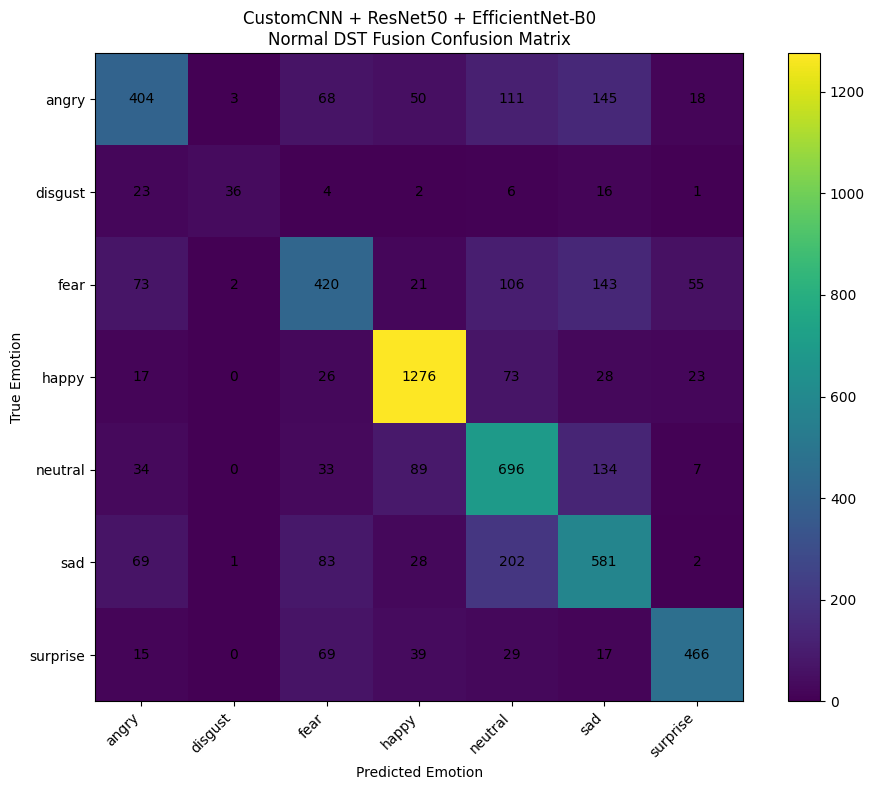

Saved PNG: /kaggle/working/final_normal_dst_fusion_confusion_matrix.png


In [65]:
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    true_labels,
    all_models_pred,
    labels=list(range(len(class_names)))
)

fig, ax = plt.subplots(figsize=(10, 8))

image = ax.imshow(cm)
fig.colorbar(image, ax=ax)

ax.set_xticks(np.arange(len(class_names)))
ax.set_yticks(np.arange(len(class_names)))
ax.set_xticklabels(class_names, rotation=45, ha="right")
ax.set_yticklabels(class_names)

ax.set_xlabel("Predicted Emotion")
ax.set_ylabel("True Emotion")
ax.set_title(
    "CustomCNN + ResNet50 + EfficientNet-B0\nNormal DST Fusion Confusion Matrix"
)

for i in range(len(class_names)):
    for j in range(len(class_names)):
        ax.text(j, i, str(cm[i, j]), ha="center", va="center")

plt.tight_layout()

SAVE_PATH = "/kaggle/working/final_normal_dst_fusion_confusion_matrix.png"
plt.savefig(SAVE_PATH, dpi=300, bbox_inches="tight")

plt.show()
plt.close()

print("Saved PNG:", SAVE_PATH)

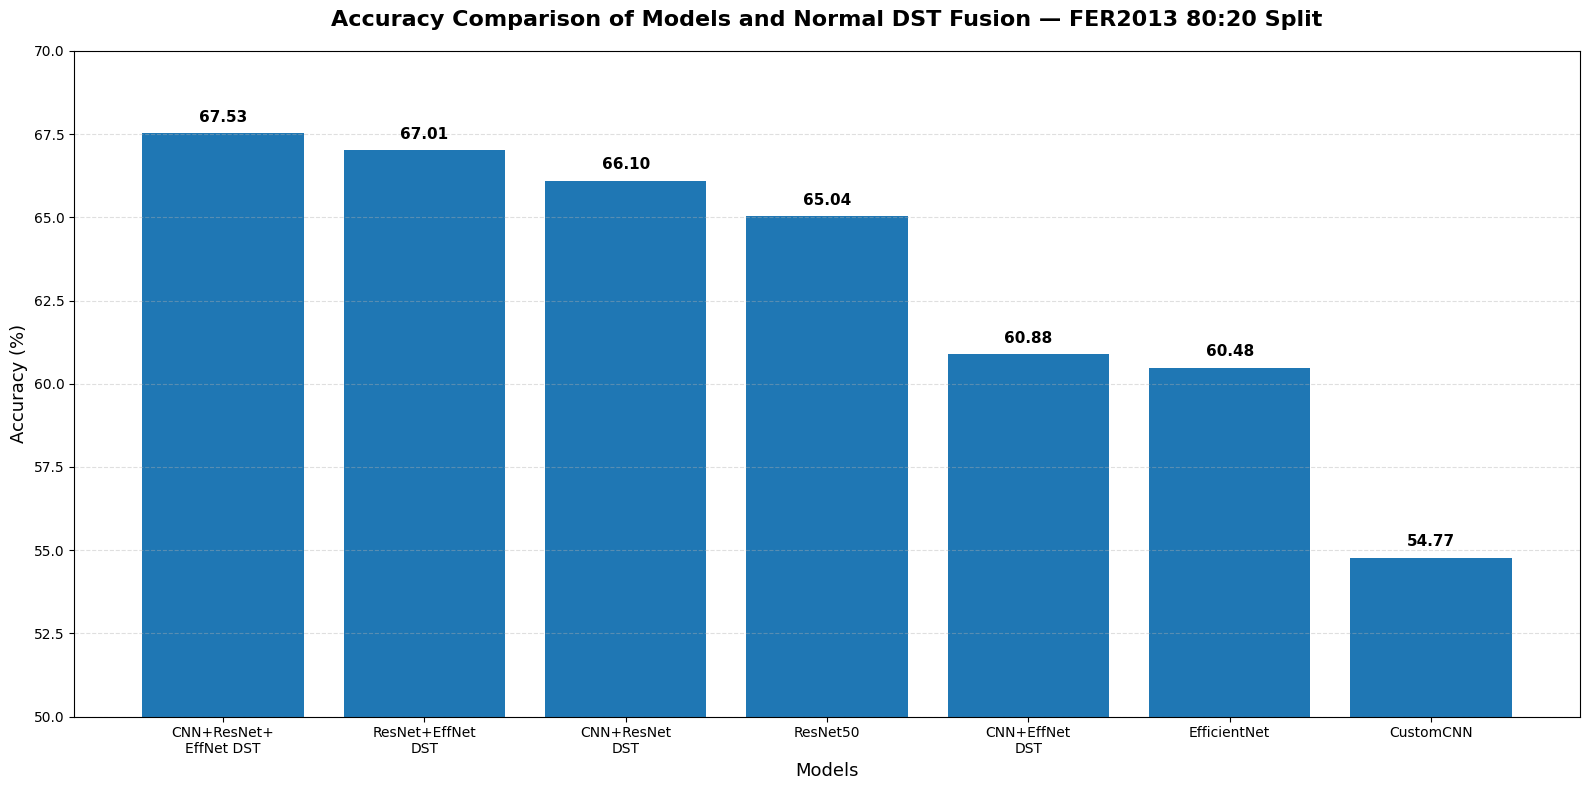

PNG saved: /kaggle/working/fer2013_accuracy_comparison_normal_dst.png


In [8]:
import matplotlib.pyplot as plt

models = [
    "CNN+ResNet+\nEffNet DST",
    "ResNet+EffNet\nDST",
    "CNN+ResNet\nDST",
    "ResNet50",
    "CNN+EffNet\nDST",
    "EfficientNet",
    "CustomCNN"
]

accuracies = [
    67.53,
    67.01,
    66.10,
    65.04,
    60.88,
    60.48,
    54.77
]

plt.figure(figsize=(16, 8))

bars = plt.bar(models, accuracies)

plt.title(
    "Accuracy Comparison of Models and Normal DST Fusion — FER2013 80:20 Split",
    fontsize=16,
    fontweight="bold",
    pad=18
)

plt.xlabel("Models", fontsize=13)
plt.ylabel("Accuracy (%)", fontsize=13)

# Zoomed scale like your example
plt.ylim(50, 70)

plt.grid(axis="y", linestyle="--", alpha=0.4)

for bar, accuracy in zip(bars, accuracies):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        accuracy + 0.25,
        f"{accuracy:.2f}",
        ha="center",
        va="bottom",
        fontsize=11,
        fontweight="bold"
    )

plt.tight_layout()

SAVE_PATH = "/kaggle/working/fer2013_accuracy_comparison_normal_dst.png"

plt.savefig(
    SAVE_PATH,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("PNG saved:", SAVE_PATH)